# 08 · Autoencoder: a rede aprende a resumir o paciente sem ver o diagnóstico

Até aqui todas as redes foram **supervisionadas**: aprenderam a prever `cardio`. O
autoencoder aprende sem rótulo nenhum. Ele tem duas metades:

* **codificador** — espreme as 16 entradas num **gargalo** de 2 números (o *espaço
  latente*);
* **decodificador** — tenta reconstruir as 16 entradas só a partir desses 2 números.

Para reconstruir bem, a rede é obrigada a descobrir o que há de mais essencial em cada
paciente. É a mesma pergunta do projeto de agrupamento (Tema 6), agora com uma rede
neural. O PCA faz a mesma compressão, mas só de forma **linear**, e serve de linha de
base.

Três usos: (1) um **mapa** dos pacientes em 2D; (2) o espaço latente como **atributos**
para prever a doença; (3) a **detecção de registros atípicos** pelo erro de reconstrução.

In [1]:
import sys
from pathlib import Path

# Permite importar `src` mesmo fora do ambiente do uv (ex.: Colab com o repositório clonado).
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from src import config
from src.data.dados import preparar
from src.model import autoencoder as ae
from src.utils import graficos
from src.utils.io import configurar_estilo, salvar_figura, salvar_tabela

configurar_estilo()
SECAO = "08-autoencoder"
P = preparar()

## 1. Treino: reconstruir a própria entrada

Arquitetura em funil espelhado: 16 → 32 → 16 → **2** → 16 → 32 → 16. A perda é o erro
quadrático médio entre a entrada e a reconstrução, e o diagnóstico não entra em nenhum momento.

Épocas: 185


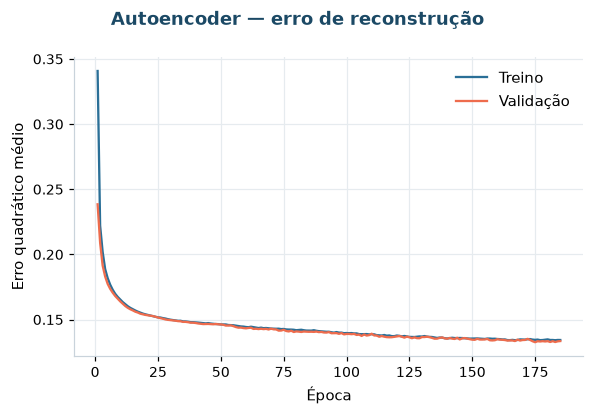

In [2]:
autoencoder, codificador = ae.construir_autoencoder(P.n_entradas, ocultas=(32, 16), latente=2)
hist = ae.treinar(autoencoder, P.X_treino, P.X_val)
print(f"Épocas: {len(hist.history['loss'])}")
fig, dados = graficos.curvas_de_treino(hist.history, "Autoencoder — erro de reconstrução")
fig.axes[0].set_ylabel("Erro quadrático médio")
salvar_figura(fig, SECAO, "curvas-treino", dados)
plt.show()

### Autoencoder × PCA com o mesmo número de dimensões

Se a rede não linear resume melhor que o PCA, ela reconstrói os pacientes com menos erro
usando os mesmos 2 números. Também treinamos versões com 4 dimensões.

In [3]:
representacoes = {}
linhas = []
for dimensoes in (2, 4):
    if dimensoes == 2:
        aut, cod = autoencoder, codificador
    else:
        aut, cod = ae.construir_autoencoder(P.n_entradas, ocultas=(32, 16), latente=dimensoes)
        ae.treinar(aut, P.X_treino, P.X_val)
    pca = PCA(dimensoes, random_state=config.SEMENTE).fit(P.X_treino)
    reconstruido_pca = pca.inverse_transform(pca.transform(P.X_val))
    linhas.append({
        "dimensoes": dimensoes,
        "erro_autoencoder": ae.erro_reconstrucao(aut, P.X_val).mean(),
        "erro_pca": ((P.X_val - reconstruido_pca) ** 2).mean(),
    })
    representacoes[f"Autoencoder ({dimensoes}D)"] = (cod.predict(P.X_treino, verbose=0), cod.predict(P.X_val, verbose=0))
    representacoes[f"PCA ({dimensoes}D)"] = (pca.transform(P.X_treino), pca.transform(P.X_val))
reconstrucao = pd.DataFrame(linhas).set_index("dimensoes")
reconstrucao["reducao_do_erro"] = 1 - reconstrucao["erro_autoencoder"] / reconstrucao["erro_pca"]
salvar_tabela(reconstrucao.round(4), SECAO, "reconstrucao-ae-vs-pca")
reconstrucao.round(4)

,erro_autoencoder,erro_pca,reducao_do_erro
dimensoes,,,
2,0.1327,0.2140,0.3802
4,0.0609,0.0835,0.2703


## 2. O mapa dos pacientes

Cada ponto é um paciente da validação, posicionado pelos 2 números do espaço latente. As
cores mostram o diagnóstico e a pressão sistólica, que **não** guiaram a compressão.

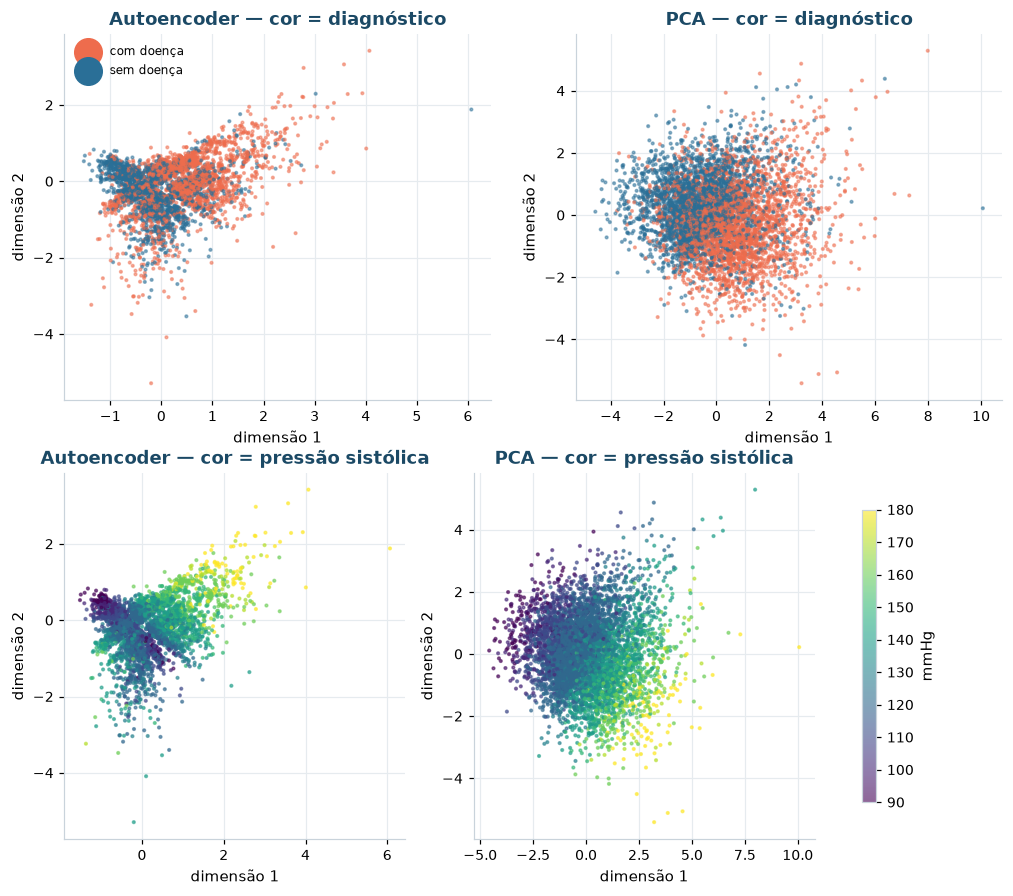

In [4]:
rng = np.random.default_rng(config.SEMENTE)
idx = rng.choice(len(P.y_val), 6000, replace=False)
Z_ae = representacoes["Autoencoder (2D)"][1][idx]
Z_pca = representacoes["PCA (2D)"][1][idx]
pressao = P.bruto_val["ap_hi"].to_numpy()[idx]
cores_cardio = np.where(P.y_val[idx] == 1, config.CORAL, config.AZUL_COBALTO)

fig, eixos = plt.subplots(2, 2, figsize=(11, 9.5))
for coluna, (nome, Z) in enumerate([("Autoencoder", Z_ae), ("PCA", Z_pca)]):
    eixos[0, coluna].scatter(Z[:, 0], Z[:, 1], s=3, c=cores_cardio, alpha=0.5)
    eixos[0, coluna].set(title=f"{nome} — cor = diagnóstico", xlabel="dimensão 1", ylabel="dimensão 2")
    pontos = eixos[1, coluna].scatter(Z[:, 0], Z[:, 1], s=3, c=np.clip(pressao, 90, 180), cmap="viridis", alpha=0.6)
    eixos[1, coluna].set(title=f"{nome} — cor = pressão sistólica", xlabel="dimensão 1", ylabel="dimensão 2")
fig.colorbar(pontos, ax=eixos[1, :], shrink=0.8, label="mmHg")
eixos[0, 0].scatter([], [], c=config.CORAL, label="com doença")
eixos[0, 0].scatter([], [], c=config.AZUL_COBALTO, label="sem doença")
eixos[0, 0].legend(markerscale=3, fontsize=8)
mapa = pd.DataFrame({"ae_1": Z_ae[:, 0], "ae_2": Z_ae[:, 1], "pca_1": Z_pca[:, 0], "pca_2": Z_pca[:, 1],
                     "cardio": P.y_val[idx], "ap_hi": pressao})
salvar_figura(fig, SECAO, "mapa-latente", mapa)
plt.show()

In [5]:
# O que cada dimensão do espaço latente captura: correlação com as variáveis originais.
Z_val_ae = representacoes["Autoencoder (2D)"][1]
correlacoes = pd.DataFrame({
    f"dimensão {d + 1}": [np.corrcoef(Z_val_ae[:, d], P.bruto_val[c])[0, 1] for c in config.ENTRADAS]
    for d in range(2)
}, index=[config.ROTULOS[c] for c in config.ENTRADAS])
correlacoes["cardio (não usado no treino)"] = [np.nan] * len(correlacoes)
correlacoes.loc["Diagnóstico (cardio)"] = [np.corrcoef(Z_val_ae[:, d], P.y_val)[0, 1] for d in range(2)] + [np.nan]
correlacoes = correlacoes.drop(columns="cardio (não usado no treino)").round(2)
salvar_tabela(correlacoes, SECAO, "latente-correlacoes")
correlacoes.sort_values("dimensão 1", key=abs, ascending=False)

,dimensão 1,dimensão 2
Pressão sistólica,0.71,0.38
Pressão diastólica,0.64,0.31
IMC,0.55,-0.45
Peso (kg),0.48,-0.52
Idade (anos),0.42,0.21
Diagnóstico (cardio),0.36,0.13
Colesterol,0.25,0.07
Glicose,0.14,0.02
Altura (cm),-0.10,-0.16
Sexo masculino,-0.03,-0.03


O autoencoder organiza os pacientes em **dois braços**. No primeiro, de pressão alta, quase
todos têm a doença; no segundo, de pressão baixa ou normal, quase nenhum tem. A tabela de
correlações mostra o que as dimensões capturam: a dimensão 1 combina **pressão, IMC, peso
e idade**, e a 2 separa **peso/IMC** de **pressão**. Fumo, álcool, atividade e sexo quase
não aparecem: com só 2 números, a rede guarda primeiro as variáveis contínuas, que mais
pesam no erro de reconstrução.

O PCA, restrito a uma projeção linear, produz uma nuvem única em que a pressão cresce
numa direção. A rede, sem nunca ter visto o diagnóstico, separou os pacientes por uma
estrutura muito parecida com a da doença, porque pressão e idade dominam tanto a variação
dos dados quanto o risco.

## 3. O espaço latente como atributos

Se a compressão guardou o que importa para a doença, uma regressão logística treinada só
com os 2 (ou 4) números do espaço latente deveria prever `cardio` quase tão bem quanto com
as 16 variáveis.

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier

linhas = []
entradas = {**representacoes, "16 variáveis originais": (P.X_treino, P.X_val)}
for nome, (Z_treino, Z_val) in entradas.items():
    logit = LogisticRegression(max_iter=1000).fit(Z_treino, P.y_treino)
    arvores = HistGradientBoostingClassifier(random_state=config.SEMENTE).fit(Z_treino, P.y_treino)
    linhas.append({
        "atributos": nome,
        "n_atributos": Z_treino.shape[1],
        "auc_val_logistica": roc_auc_score(P.y_val, logit.predict_proba(Z_val)[:, 1]),
        "auc_val_gradient_boosting": roc_auc_score(P.y_val, arvores.predict_proba(Z_val)[:, 1]),
    })
atributos = pd.DataFrame(linhas).set_index("atributos").sort_values("auc_val_gradient_boosting", ascending=False)
salvar_tabela(atributos.round(4), SECAO, "latente-como-atributo")
atributos.round(4)

,n_atributos,auc_val_logistica,auc_val_gradient_boosting
atributos,,,
16 variáveis originais,16,0.7920,0.8019
PCA (4D),4,0.7777,0.7856
Autoencoder (4D),4,0.7717,0.7839
PCA (2D),2,0.7761,0.7746
Autoencoder (2D),2,0.7185,0.7699


Duas lições na tabela:

* **A estrutura do autoencoder não é linear.** Com a regressão logística, os 2 números do
  autoencoder rendem bem menos que os 2 do PCA; com o Gradient Boosting, que acompanha
  curvas e braços, a diferença quase some. A informação está lá, mas dobrada.
* **Comprimir bem ≠ separar bem a doença.** Mesmo reconstruindo os pacientes com ~27–38 %
  menos erro que o PCA, o espaço latente do autoencoder não prevê `cardio` melhor que o do
  PCA, e nenhum dos dois chega às 16 variáveis originais. O autoencoder otimiza a
  reconstrução de **todas** as variáveis; parte do que ele guarda (peso, altura) importa
  pouco para a doença. Quando há rótulo, a rede supervisionada é o caminho direto.

## 4. Registros atípicos: quem a rede não consegue reconstruir

Um paciente que foge do padrão da base é reconstruído com erro alto. Usamos o
autoencoder de 4 dimensões, que reconstrói melhor os pacientes comuns e, por isso,
destaca melhor os incomuns.

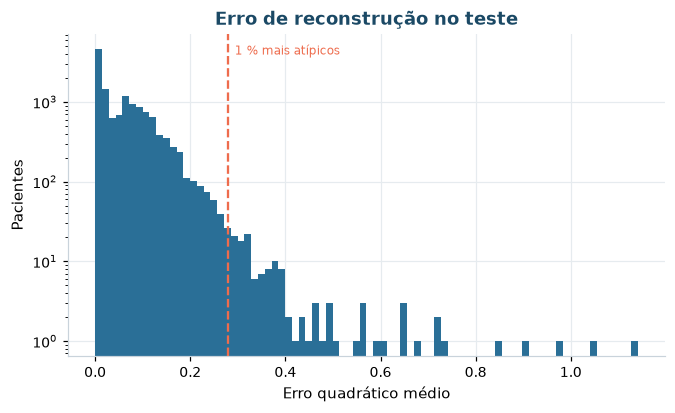

,1 % mais atípicos,demais pacientes
idade_anos,53.88,53.26
height,165.15,164.51
weight,79.01,74.07
imc,28.96,27.41
ap_hi,156.12,126.36
ap_lo,86.21,81.29
cholesterol,1.88,1.36
gluc,1.74,1.22
sexo_masculino,0.44,0.35
smoke,0.24,0.09


In [7]:
aut4, _ = ae.construir_autoencoder(P.n_entradas, ocultas=(32, 16), latente=4)
ae.treinar(aut4, P.X_treino, P.X_val)
erro = ae.erro_reconstrucao(aut4, P.X_teste)
corte = np.quantile(erro, 0.99)
teste = P.bruto_teste.assign(cardio=P.y_teste.astype(int), erro=erro,
                             pressao_de_pulso=P.bruto_teste["ap_hi"] - P.bruto_teste["ap_lo"])
atipicos = teste[teste["erro"] >= corte]

fig, eixo = plt.subplots(figsize=(7, 3.8))
eixo.hist(erro, bins=80, color=config.AZUL_COBALTO)
eixo.axvline(corte, color=config.CORAL, linestyle="--")
eixo.text(corte * 1.05, eixo.get_ylim()[1] * 0.8, "1 % mais atípicos", color=config.CORAL, fontsize=8)
eixo.set(title="Erro de reconstrução no teste", xlabel="Erro quadrático médio", ylabel="Pacientes", yscale="log")
salvar_figura(fig, SECAO, "erro-reconstrucao", pd.DataFrame({"erro": erro}))
plt.show()

perfil = pd.DataFrame({
    "1 % mais atípicos": atipicos.drop(columns="erro").mean(),
    "demais pacientes": teste[teste["erro"] < corte].drop(columns="erro").mean(),
}).round(2)
salvar_tabela(perfil, SECAO, "perfil-atipicos")
salvar_tabela(atipicos.sort_values("erro", ascending=False).head(15).round(2), SECAO, "atipicos-top15")
perfil

In [8]:
atipicos.sort_values("erro", ascending=False).head(10).round(2)

,idade_anos,height,weight,imc,ap_hi,ap_lo,cholesterol,gluc,sexo_masculino,smoke,alco,active,cardio,erro,pressao_de_pulso
13403,47.95,166,87.0,31.57,190,60,2,1,0,0,0,1,1,1.14,130
5333,53.36,169,80.0,28.01,200,160,3,3,0,0,0,1,0,1.05,40
1199,59.46,172,64.0,21.63,150,40,1,2,1,0,0,1,1,0.98,110
3800,40.07,178,77.0,24.30,190,70,1,1,1,1,0,0,1,0.90,120
13197,50.11,165,76.0,27.92,240,100,1,1,1,0,0,1,1,0.85,140
7260,47.56,160,68.0,26.56,160,45,1,1,0,0,0,1,1,0.73,115
4853,59.96,174,77.0,25.43,160,60,1,1,1,0,0,1,1,0.72,100
8584,55.59,175,95.0,31.02,210,90,3,3,1,0,0,1,1,0.72,120
8431,55.20,154,91.0,38.37,160,60,3,1,0,0,0,1,1,0.67,100
5403,60.09,158,80.0,32.05,160,60,1,1,0,0,0,1,1,0.65,100


Os pacientes mais atípicos têm um padrão claro: **pressão de pulso muito alta** (diferença
entre sistólica e diastólica de 100 a 140 mmHg, como 190/60 ou 150/40) ou combinações
extremas como 200/160 e 240/100. São casos raros e, em parte, **suspeitos de erro de
digitação**, que passaram pelos filtros de plausibilidade da curadoria porque cada valor
isolado é possível. O grupo também concentra mais fumantes, consumo de álcool, colesterol
e glicose alterados, e 77 % dele tem a doença, contra 49 % no restante.

## Conclusões

* O autoencoder aprendeu, **sem ver o diagnóstico**, uma representação em que pressão,
  idade e tamanho corporal organizam os pacientes. É a mesma hierarquia de variáveis que as
  redes supervisionadas usam, descoberta de outro jeito.
* Ele comprime melhor que o PCA (erro de reconstrução ~27–38 % menor), mas a compressão
  não supervisionada não substitui o treino supervisionado quando há rótulo.
* O erro de reconstrução é um **filtro de qualidade de dados** útil: aponta registros que
  cada filtro de faixa, sozinho, deixaria passar. Numa operação real, esses pacientes
  seriam os primeiros a ter o prontuário revisado.
* Diálogo com o Tema 6: lá o agrupamento segmentou os pacientes com métodos clássicos;
  aqui uma rede neural encontrou uma estrutura contínua (os braços) em vez de grupos
  separados, o que sugere que os perfis da base variam de forma gradual, não em
  categorias estanques.